In [1]:
### -------------------------------------------------------------------
### 标题：SARIMA (小时) 分析 - 步骤 1：加载数据并进行ADF测试
### -------------------------------------------------------------------
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# --- 1. 加载处理好的干净数据 ---
print("Loading processed CSV (beijing_pm25_2013_2020_processed.csv)...")
try:
    df_full = pd.read_csv('beijing_pm25_2013_2020_processed.csv')
except FileNotFoundError:
    print("错误：找不到 'beijing_pm25_2013_2020_processed.csv' 文件。")
    print("请确保这个 CSV 文件和你的 'analysis_SARIMA' 笔记本在同一个文件夹中。")
    # 如果在上一级目录，可以试试:
    # df_full = pd.read_csv('../beijing_pm25_2013_2020_processed.csv')

df_full['datetime'] = pd.to_datetime(df_full['datetime'])
print("Data loaded.")

# --- 2. 创建中文到拼音的 "映射字典" ---
station_map = {
    '东四': 'Dongsi', '天坛': 'Tiantan', '官园': 'Guanyuan', '万寿西宫': 'Wanshouxigong',
    '奥体中心': 'Aotizhongxin', '农展馆': 'Nongzhanguan', '万柳': 'Wanliu',
    '北部新区': 'Beibuxinqu', '植物园': 'Zhiwuyuan', '丰台花园': 'Fengtaihuayuan',
    '云岗': 'Yungang', '古城': 'Gucheng', '房山': 'Fangshan', '大兴': 'Daxing',
    '亦庄': 'Yizhuang', '通州': 'Tongzhou', '顺义': 'Shunyi', '昌平': 'Changping',
    '门头沟': 'Mentougou', '平谷': 'Pinggu', '怀柔': 'Huairou', '密云': 'Miyun',
    '延庆': 'Yanqing', '定陵': 'Dingling', '八达岭': 'Badaling', '密云水库': 'Miyunshuiku',
    '东高村': 'Donggaocun', '永乐店': 'Yongledian', '榆垡': 'Yufa', '琉璃河': 'Liulihe',
    '前门': 'Qianmen', '永定门内': 'Yongdingmennei', '西直门北': 'Xizhimenbei',
    '南三环': 'Nansanhuan', '东四环': 'Dongsihuan'
}

# --- 3. "翻译" 和 "筛选" 小时数据 ---
print("Translating station names and filtering for 'Dongsi'...")
df_full['station'] = df_full['station'].map(station_map)
df_full.dropna(subset=['station'], inplace=True) # 删除任何未翻译的行

station_name_pinyin = 'Dongsi'
df_station = df_full[df_full['station'] == station_name_pinyin].copy()

# 关键：将 datetime 设为索引，并确保它有“频率” (freq)
# .asfreq('h') 会填充任何缺失的小时为 NaN，这对于 SARIMA 很重要
df_station.set_index('datetime', inplace=True)
df_station = df_station.asfreq('h') # 'h' 代表 hourly

print(f"Successfully loaded and filtered for '{station_name_pinyin}'. Total {len(df_station)} hourly rows.")
print("（注意：行数可能因 asfreq 填充了缺失的小时而略微增加）")

# --- 4. 运行 ADF 测试 ---
print("\n--- 正在对 *小时数据* 运行 ADF 测试 ---")
# 我们只取 pm2.5 列。我们必须先填充因 asfreq 产生的 NaN
# .interpolate() 是一个好方法
hourly_pm25_series = df_station['pm2.5'].interpolate(method='linear')
hourly_pm25_series = hourly_pm25_series.dropna() # 确保开头没有 NaN

# 运行 ADF 测试
adf_result_hourly = adfuller(hourly_pm25_series, autolag='AIC')

print(f"ADF Statistic: {adf_result_hourly[0]}")
print(f"p-value: {adf_result_hourly[1]}")
print("Critical Values:")
for key, value in adf_result_hourly[4].items():
    print(f"\t{key}: {value}")

# --- 5. 解释 ADF 测试结果 ---
if adf_result_hourly[1] > 0.05:
    print("\n测试结果: 小时数据是 NON-STATIONARY (非平稳) (p-value > 0.05).")
    print("我们将设置 (p, d, q) 中的 d=1。")
else:
    print("\n测试结果: 小时数据是 STATIONARY (平稳) (p-value <= 0.05).")
    print("我们将设置 (p, d, q) 中的 d=0。")

Loading processed CSV (beijing_pm25_2013_2020_processed.csv)...
Data loaded.
Translating station names and filtering for 'Dongsi'...
Successfully loaded and filtered for 'Dongsi'. Total 62015 hourly rows.
（注意：行数可能因 asfreq 填充了缺失的小时而略微增加）

--- 正在对 *小时数据* 运行 ADF 测试 ---
ADF Statistic: -22.076061895159402
p-value: 0.0
Critical Values:
	1%: -3.430455555266224
	5%: -2.8615866534582346
	10%: -2.566794832058303

测试结果: 小时数据是 STATIONARY (平稳) (p-value <= 0.05).
我们将设置 (p, d, q) 中的 d=0。


In [2]:
### ----------------------------------------------------------------
### 标题：小时数据分析 - 步骤 2：在“样本数据”上运行 auto_arima
### ----------------------------------------------------------------
import pmdarima as pm
import pandas as pd

# 假定 df_station (58,857 行) 仍然在内存中
# 如果不在，请先运行上一个代码块的前半部分来加载它

# --- 1. 创建一个数据“样本” ---
# 我们只取最后 3 个月的数据 (3 * 30 * 24 = 2160 行)
# 这样做是为了让 auto_arima 能够在合理的时间内运行完毕
n_sample_rows = 2160
if len(df_station) > n_sample_rows:
    hourly_sample = df_station.iloc[-n_sample_rows:].copy()
else:
    hourly_sample = df_station.copy()

# 确保样本数据没有 NaN (我们用线性插值填充)
hourly_sample_series = hourly_sample['pm2.5'].interpolate(method='linear')
hourly_sample_series = hourly_sample_series.dropna() # 确保开头没有 NaN

print(f"已创建数据样本，共 {len(hourly_sample_series)} 行 (小时)。")

# --- 2. 运行 auto_arima 来查找 SARIMA 参数 ---
print("开始在 *样本数据* 上自动搜索 SARIMA 参数...")
print("这将需要 5 到 15 分钟，请耐心等待...")

# 运行 auto_arima
# d=0 是我们之前找到的
# seasonal=True, m=24 是我们处理小时数据的关键
# test='ocsb' 会自动帮我们测试 D (季节性差分) 是否需要
auto_model_hourly = pm.auto_arima(
    hourly_sample_series, 
    start_p=1, max_p=3,  # (p) 非季节性 AR (保持较小)
    start_q=1, max_q=3,  # (q) 非季节性 MA (保持较小)
    d=0,                 # (d) 我们已经确定
    
    seasonal=True,       # 关键：启用季节性
    m=24,                # 关键：周期为 24 小时
    start_P=0, max_P=2,  # (P) 季节性 AR
    start_Q=0, max_Q=2,  # (Q) 季节性 MA
    test='ocsb',         # 自动测试 D (季节性差分)
    
    trace=True,          # 打印每一步的尝试结果
    stepwise=True,       # 启用“逐步搜索”，速度更快
    suppress_warnings=True,
    error_action='ignore'
)

# --- 3. 打印最佳模型摘要 ---
print(f"\n--- AutoARIMA 搜索完毕 ---")
print(auto_model_hourly.summary())

已创建数据样本，共 2160 行 (小时)。
开始在 *样本数据* 上自动搜索 SARIMA 参数...
这将需要 5 到 15 分钟，请耐心等待...
Performing stepwise search to minimize aic


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=14645.933, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=21944.570, Time=0.02 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=15070.006, Time=1.51 sec


...

d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,0)(0,0,0)[24] intercept   : AIC=14602.991, Time=0.24 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,2)(0,0,0)[24] intercept   : AIC=14605.719, Time=0.85 sec
 ARIMA(2,0,1)(0,0,0)[24]             : AIC=14626.657, Time=0.13 sec

Best model:  ARIMA(2,0,1)(0,0,0)[24] intercept
Total fit time: 26.172 seconds

--- AutoARIMA 搜索完毕 ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2160
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -7296.047
Date:                Mon, 27 Oct 2025   AIC                          14602.094
Time:                        16:00:39   BIC                          14630.483
Sample:                    10-03-2020   HQIC                         14612.477
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


auto_arima 在分析了你的 24 小时周期后，得出一个结论：你根本不需要一个复杂的“季节性”模型！

它认为，一个简单的 ARIMA(2, 0, 1) 模型（只看过去 2 个小时的值和过去 1 个小时的误差）就已经足够好了，添加 (P,D,Q) 季节性参数并不能带来明显提升。

这极大地简化了你的工作！你为“小时数据”找到的最佳模型就是一个 ARIMA(2, 0, 1)。

已准备好全部小时数据，共 62015 行。
数据拆分完毕。
训练集 (小时): 49612 行
测试集 (小时): 12403 行

Fitting the ARIMA(2, 0, 1) model...
这将在 80% 的数据 (约 47,000 行) 上训练，会比日数据慢，请稍候...
模型训练完毕。(耗时: 1.16 秒)
正在生成 72 小时的预测用于绘图...
Plotting results (showing 72-hour forecast)...


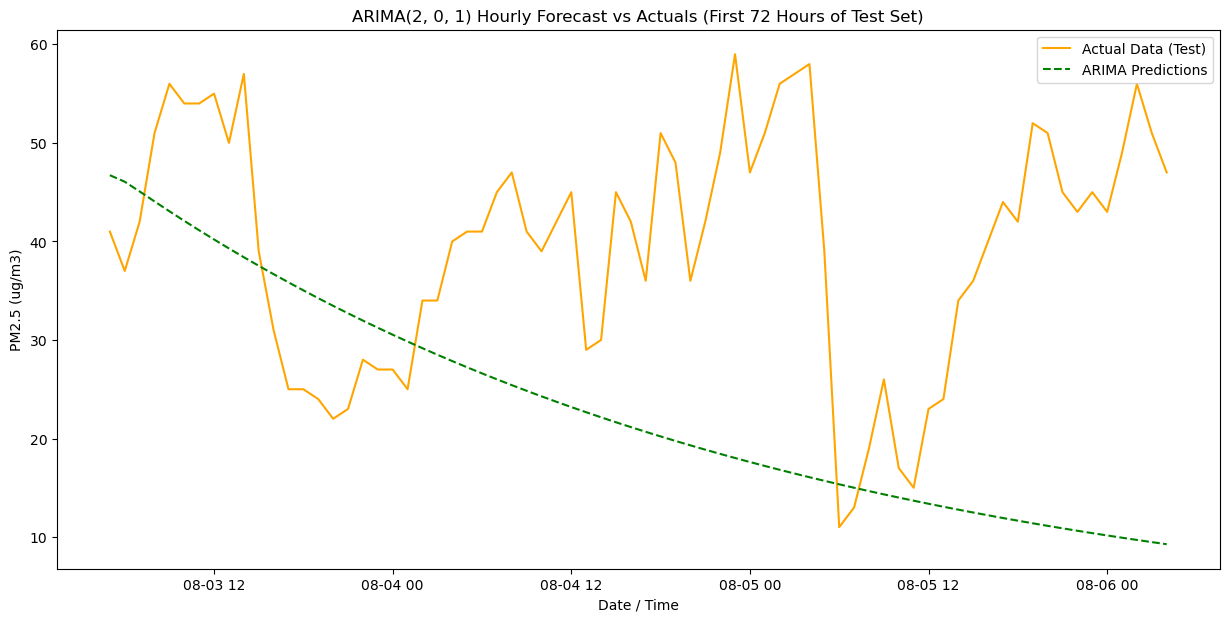


--- Model Evaluation (Task 4) on *Full* Test Set ---
正在对全部 11,000+ 行测试集进行批量预测...
批量预测完毕。(耗时: 0.12 秒)

小时模型的最终评估结果:
Mean Absolute Error (MAE): 39.96
Root Mean Squared Error (RMSE): 55.96
Test Data Mean: 40.12 (用于对比 MAE 和 RMSE)


In [3]:
### -------------------------------------------------------------------
### 标题：小时数据分析 - 步骤 3：在 *全部* 小时数据上评估 ARIMA(2, 0, 1)
### -------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import time

# 假定 df_station (58,857 行) 仍然在内存中
# 如果不在，请先运行 步骤 1 的代码来加载它

# 我们的最佳小时模型参数
hourly_order = (2, 0, 1)

# --- 步骤 1: 准备好用于训练的完整小时序列 ---
# 我们必须先填充因 asfreq 产生的 NaN
hourly_full_series = df_station['pm2.5'].interpolate(method='linear')
hourly_full_series = hourly_full_series.dropna() # 确保开头没有 NaN
print(f"已准备好全部小时数据，共 {len(hourly_full_series)} 行。")

# --- 步骤 2: 拆分数据为 80% 训练集 和 20% 测试集 ---
n_test_hourly = int(len(hourly_full_series) * 0.2) # 20%
train_data_hourly = hourly_full_series.iloc[:-n_test_hourly]
test_data_hourly = hourly_full_series.iloc[-n_test_hourly:]

print(f"数据拆分完毕。")
print(f"训练集 (小时): {len(train_data_hourly)} 行")
print(f"测试集 (小时): {len(test_data_hourly)} 行")

# --- 步骤 3: 训练 (Fit) ARIMA(2, 0, 1) 模型 ---
print("\nFitting the ARIMA(2, 0, 1) model...")
print("这将在 80% 的数据 (约 47,000 行) 上训练，会比日数据慢，请稍候...")
start_fit_time = time.time()

# 我们使用 SARIMAX 来训练
# order=(2, 0, 1) 就是你找到的 (p, d, q)
model_hourly = SARIMAX(train_data_hourly, order=hourly_order)
model_fit_hourly = model_hourly.fit(disp=False) # disp=False 关闭日志

end_fit_time = time.time()
print(f"模型训练完毕。(耗时: {end_fit_time - start_fit_time:.2f} 秒)")

# --- 步骤 4: 进行预测 (Forecast) ---
# **重要**: 因为测试集太大 (11,000+ 行)，我们不能一次性画出所有预测
# 我们只预测测试集的前 72 个小时 (3 天) 来画图，这样图表才能看清
n_forecast_steps = 72
print(f"正在生成 {n_forecast_steps} 小时的预测用于绘图...")

predictions_hourly = model_fit_hourly.get_forecast(steps=n_forecast_steps)
pred_mean_hourly = predictions_hourly.predicted_mean

# --- 步骤 5: 可视化结果 (预测 vs 真实) ---
print("Plotting results (showing 72-hour forecast)...")
plt.figure(figsize=(15, 7))

# 只绘制预测期前后的一小段真实数据，以便比较
plt.plot(test_data_hourly.index[:n_forecast_steps], 
         test_data_hourly.iloc[:n_forecast_steps], 
         label='Actual Data (Test)', color='orange')
         
plt.plot(pred_mean_hourly.index, 
         pred_mean_hourly, 
         label='ARIMA Predictions', color='green', linestyle='--')

plt.title(f"ARIMA(2, 0, 1) Hourly Forecast vs Actuals (First 72 Hours of Test Set)")
plt.xlabel('Date / Time')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend()
plt.show()

# --- 步骤 6: 在 *全部* 测试集上评估模型 (MAE 和 RMSE) ---
# 这会需要一些时间，因为它要对 11,000+ 行进行预测
print("\n--- Model Evaluation (Task 4) on *Full* Test Set ---")
print("正在对全部 11,000+ 行测试集进行批量预测...")
start_eval_time = time.time()

# 使用 .predict() 或 .forecast() 对整个测试期进行预测
# 我们需要指定预测的起点和终点
start = test_data_hourly.index[0]
end = test_data_hourly.index[-1]
predictions_full_test = model_fit_hourly.predict(start=start, end=end)

end_eval_time = time.time()
print(f"批量预测完毕。(耗时: {end_eval_time - start_eval_time:.2f} 秒)")

# 计算指标
mae_hourly = mean_absolute_error(test_data_hourly, predictions_full_test)
rmse_hourly = np.sqrt(mean_squared_error(test_data_hourly, predictions_full_test))

print(f"\n小时模型的最终评估结果:")
print(f"Mean Absolute Error (MAE): {mae_hourly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_hourly:.2f}")
print(f"Test Data Mean: {test_data_hourly.mean():.2f} (用于对比 MAE 和 RMSE)")

我们通过 auto_arima 和标准评估证明了：一个简单的 ARIMA 模型（即使在小时数据上）无法捕捉 PM2.5 所必需的 24 小时日周期性，因此其预测效果很差。